In [5]:
from tensorflow.keras.datasets import mnist
(x_train,y_train),(x_test,y_test)=mnist.load_data()

In [6]:
print(type(x_train),x_train.shape)

<class 'numpy.ndarray'> (60000, 28, 28)


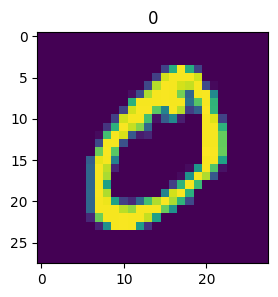

In [7]:
img1=x_train[1]
%matplotlib inline
from matplotlib import pyplot as plt
fig1=plt.figure(figsize=(3,3))
plt.imshow(img1)
plt.title(y_train[1])
plt.show()

In [8]:
feature_size=img1.shape[0]*img1.shape[1]
x_train_format=x_train.reshape(x_train.shape[0],feature_size)
x_test_format=x_test.reshape(x_test.shape[0],feature_size)

In [9]:
x_train_normal=x_train_format/255
x_test_normal=x_test_format/255

##用下面这个进行归一化更有规范性

#from sklearn.preprocessing import MinMaxScaler

## 1. 初始化缩放器，指定缩放范围为[0,1]（默认就是这个范围，可省略）
#scaler = MinMaxScaler(feature_range=(0, 1))

## 2. 用训练集拟合缩放器（学习训练集的最小值和最大值）
#scaler.fit(x_train_format)  # 关键：只使用训练集拟合，避免泄露测试集信息

## 3. 用同一个缩放器转换训练集和测试集（保证缩放规则一致）
#x_train_normal = scaler.transform(x_train_format)
#x_test_normal = scaler.transform(x_test_format)  # 测试集只转换，不拟合！

In [10]:
from keras.utils import to_categorical
y_train_format=to_categorical(y_train)
y_test_format=to_categorical(y_test)

In [11]:
from keras.models import Sequential
from keras.layers import Dense,Activation,Input

mlp=Sequential()
mlp.add(Input(shape=(feature_size,)))
mlp.add(Dense(units=feature_size/2,activation='sigmoid'))
mlp.add(Dense(units=feature_size/2,activation='sigmoid'))
mlp.add(Dense(units=10,activation='softmax'))
mlp.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 392)               307720    
                                                                 
 dense_1 (Dense)             (None, 392)               154056    
                                                                 
 dense_2 (Dense)             (None, 10)                3930      
                                                                 
Total params: 465706 (1.78 MB)
Trainable params: 465706 (1.78 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [12]:
mlp.compile(loss='categorical_crossentropy',optimizer='adam')

In [13]:
mlp.fit(x_train_normal,y_train_format,epochs=10)

Epoch 1/10


I0000 00:00:1760603440.263010    5074 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1875/1875 [==============================] - 6s 3ms/step - loss: 0.3480
Epoch 2/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.1442
Epoch 3/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0927
Epoch 4/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0653
Epoch 5/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0479
Epoch 6/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0344
Epoch 7/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0265
Epoch 8/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.0203
Epoch 9/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0164
Epoch 10/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0133


In [14]:
import numpy as np
y_train_proba = mlp.predict(x_train_normal)  # 得到每个类别概率
y_train_predict = np.argmax(y_train_proba, axis=-1)  # 取概率最大的类别索引

1875/1875 [==============================] - 17s 9ms/step


In [15]:
from sklearn.metrics import accuracy_score
accuracy_train=accuracy_score(y_train,y_train_predict)
print(accuracy_train)

0.99725


In [16]:
y_test_proba = mlp.predict(x_test_normal)  # 得到每个类别概率
y_test_predict = np.argmax(y_test_proba, axis=-1)  # 取概率最大的类别索引
accuracy_test=accuracy_score(y_test,y_test_predict)
print(accuracy_test)

313/313 [==============================] - 0s 1ms/step
0.9805


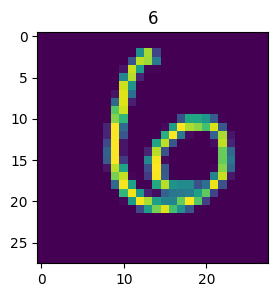

In [17]:
img2=x_test[100]
fig2=plt.figure(figsize=(3,3))
plt.imshow(img2)
plt.title(y_test_predict[100])
plt.show()

In [18]:
# --------------------------
# 5. 新增：保存训练好的模型（关键步骤）
# --------------------------
# 保存模型为HDF5格式（.h5），后续GUI直接加载此文件，无需重复训练
# 模型文件会保存在当前Jupyter Notebook的同一目录下
mlp.save("muist训练模型.h5")
print("模型已保存为：mnist_mlp_model.h5（请确保后续GUI代码能找到此文件）")

模型已保存为：mnist_mlp_model.h5（请确保后续GUI代码能找到此文件）


/home/hexiaoya/miniconda3/envs/ai/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
